# Inspecting papers

Quick reference for poking at individual papers, topics, communities, and nearest-neighbour lists. Use it to:

- look up a single paper's full metadata,
- browse the contents of a BERTopic topic or a Leiden community,
- search by keyword,
- compare a paper's embedding-NN against its citation-NN side by side,
- check data-quality issues like placeholder abstracts.

## Setup

In [24]:
import numpy as np
import pandas as pd
import networkx as nx

from citation_neighbors import nearest_neighbors as citation_nn
from embedding_neighbors import cosine_nearest_neighbors

pd.set_option('display.max_colwidth', 200)
pd.set_option('display.max_rows', 60)

In [25]:
df = pd.read_csv('data/document_topics_new.csv')
G  = nx.read_graphml('data/citation_network_with_topics_new.graphml')
topic_words = pd.read_csv('data/topic_words_new.csv')
topic_info  = pd.read_csv('data/topic_info_new.csv')

print(f'{len(df):,} papers, {G.number_of_edges():,} citation edges, {len(topic_words)} topics')

14,511 papers, 166,003 citation edges, 127 topics


## Look up a single paper

Every paper has a `node_id` of the form `n<int>`. `G.nodes[node_id]` returns a dict with all the metadata; the helper below prints the most relevant fields.

In [26]:
def show_paper(node_id, abstract_chars=400):
    d = G.nodes[node_id]
    print(f'[{node_id}]  year={d.get("year", "?")}  journal={(d.get("journal") or "?")!r}')
    print(f'  topic:     {d.get("topic", "?")}')
    print(f'  community: {d.get("cpm_communities_at_res=0.005", "?")}')
    print(f'  title:     {d.get("title", "")!r}')
    print(f'  authors:   {(d.get("authors") or "")[:200]!r}')
    abstract = d.get('abstract') or ''
    print(f'  abstract:  {abstract[:abstract_chars]!r}{" ..." if len(abstract) > abstract_chars else ""}')

show_paper('n15773')

[n15773]  year=2010.0  journal='Journal of Neurophysiology'
  topic:     54
  community: 0.0
  title:     'Size of error affects cerebellar contributions to motor learning'
  authors:   'Criscimagna-Hemminger, Sarah E.|Bastian, Amy J.|Shadmehr, Reza'
  abstract:  'Small errors may affect the process of learning in a fundamentally different way than large errors. For example, adapting reaching movements in response to a small perturbation produces generalization patterns that are different from large perturbations. Are distinct neural mechanisms engaged in response to large versus small errors? Here, we examined the motor learning process in patients with se' ...


## Browse a topic

Pick a topic id and inspect its papers. The bottom of the cell prints the top words BERTopic assigned to that topic for context.

In [27]:
def show_topic(topic_id, n=10):
    words_row = topic_words[topic_words['topic_id'] == topic_id]
    if len(words_row):
        print(f'Topic {topic_id} words: {words_row.iloc[0]["words"]}')
    ids = df.loc[df['topic'] == topic_id, 'node_id'].tolist()
    print(f'  {len(ids)} papers total\n')
    for nid in ids[:n]:
        show_paper(nid, abstract_chars=200)
        print()

show_topic(75, n=8)

Topic 75 words: abstract available | sep abstract | abstract | available | motor control | reinforcement | final | motor learning | control motor | chapter
  34 papers total

[n562]  year=2013.0  journal='Physiological Reports'
  topic:     75
  community: 80.0
  title:     'Heritability of motor control and motor learning'
  authors:   'Missitzi, Julia|Gentner, Reinhard|Misitzi, Angelica|Geladas, Nickos D.|Politis, Panagiotis K.|Klissouras, Vassilis|Claßen, Joseph'
  abstract:  'The aim of this study was to elucidate the relative contribution of genes and environment on individual differences in motor control and acquisition of a force control task, in view of recent associat' ...

[n643]  year=1998.0  journal='Neurobiology of Learning and Memory'
  topic:     75
  community: 259.0
  title:     'A comparative perspective on motor learning'
  authors:   'Striedter, Georg F.'
  abstract:  '[No abstract available]'

[n674]  year=2009.0  journal='Advances in Experimental Medicine and Biol

## Browse a Leiden community

The graphml has communities at several resolutions (`cpm_communities_at_res=0.001` ... `=0.009`). The pipeline currently uses `0.005`; swap the attribute name to look at a different resolution.

In [ ]:
COMMUNITY_ATTR = 'cpm_communities_at_res=0.005'
# incorrect, change stg;
# label by keyword (in the graph) - automatically label (similar to berttopic algo)

def show_community(community_id, n=10):
    ids = [nid for nid, d in G.nodes(data=True) if str(d.get(COMMUNITY_ATTR)) == str(community_id)]
    print(f'Community {community_id} ({COMMUNITY_ATTR}): {len(ids)} papers')
    print()
    for nid in ids[:n]:
        show_paper(nid, abstract_chars=200)
        print()

# show_community(45, n=5)

## Search by keyword

Returns matching papers as a DataFrame so you can sort, slice, etc.

In [29]:
def search(pattern, where='title', case=False, regex=False):
    """Search titles ('title'), abstracts ('abstract'), or the combined doc ('document')."""
    if where == 'document':
        mask = df['document'].fillna('').str.contains(pattern, case=case, regex=regex)
        return df.loc[mask, ['node_id', 'topic', 'document']]
    rows = []
    for nid, d in G.nodes(data=True):
        text = (d.get(where) or '')
        if pd.Series([text]).str.contains(pattern, case=case, regex=regex).iloc[0]:
            rows.append({'node_id': nid, 'year': d.get('year'), 'title': d.get('title', ''),
                         'topic': d.get('topic'), 'community': d.get(COMMUNITY_ATTR)})
    return pd.DataFrame(rows)

search('visuomotor adaptation', where='title').head(10)

,node_id,year,title,topic,community
0,n330,2009.0,The rate of visuomotor adaptation correlates with cerebellar white-matter microstructure,54,0.0
1,n1304,2003.0,Effects of Parkinson's disease on visuomotor adaptation,-1,0.0
2,n1415,2007.0,The interference effects of non-rotated versus counter-rotated trials in visuomotor adaptation.,1,0.0
3,n1455,2008.0,Asymmetric generalization between the arm and leg following prism-induced visuomotor adaptation,-1,127.0
4,n1461,2008.0,A dissociation between visual and motor workspace inhibits generalization of visuomotor adaptation across the limbs,-1,0.0
5,n1464,2008.0,Straight ahead acts as a reference for visuomotor adaptation,1,1558.0
6,n1493,2009.0,Contribution of night and day sleep vs. simple passage of time to the consolidation of motor sequence and visuomotor adaptation learning,2,1.0
7,n1509,2010.0,Real-time error detection but not error correction drives automatic visuomotor adaptation,1,0.0
8,n1519,2010.0,Visuomotor adaptation and intermanual transfer under different viewing conditions,-1,0.0
9,n1549,2010.0,Absence of after-effects for observers after watching a visuomotor adaptation,-1,6.0


## Compare embedding-NN vs citation-NN for one paper

Run the compute cell once (≈ 6 seconds for both NN dicts), then use `compare_nn(node_id)` as often as you like.

In [30]:
K = 10
CITATION_METHOD = 'combined' # co_citation, bibliographic_coupling, combined

emb = np.load('data/embeddings_cache.npz')['valid_embeddings']
node_ids = df['node_id'].tolist()

nn_emb = cosine_nearest_neighbors(emb, node_ids, k=K)
nn_cit = citation_nn(G, method=CITATION_METHOD, k=K)
print(f'computed: {len(nn_emb)} embedding NN lists, {len(nn_cit)} citation NN lists')

computed: 14511 embedding NN lists, 14511 citation NN lists


In [31]:
def compare_nn(node_id, title_chars=85):
    print('SOURCE')
    show_paper(node_id, abstract_chars=180)
    print()

    emb_set = set(nn_emb.get(node_id, []))
    cit_set = set(nn_cit.get(node_id, []))
    inter = emb_set & cit_set
    union = emb_set | cit_set
    jacc = len(inter) / len(union) if union else float('nan')
    print(f'JACCARD ({CITATION_METHOD}, k={K}): {jacc:.3f}   shared: {len(inter)}\n')

    print('EMBEDDING NN:')
    for nb in nn_emb.get(node_id, []):
        marker = '★' if nb in cit_set else ' '
        print(f'  {marker} [{nb}] {(G.nodes[nb].get("title", "") or "")[:title_chars]!r}')
    print()
    print('CITATION NN:')
    for nb in nn_cit.get(node_id, []):
        marker = '★' if nb in emb_set else ' '
        print(f'  {marker} [{nb}] {(G.nodes[nb].get("title", "") or "")[:title_chars]!r}')

compare_nn('n15773')

SOURCE
[n15773]  year=2010.0  journal='Journal of Neurophysiology'
  topic:     54
  community: 0.0
  title:     'Size of error affects cerebellar contributions to motor learning'
  authors:   'Criscimagna-Hemminger, Sarah E.|Bastian, Amy J.|Shadmehr, Reza'
  abstract:  'Small errors may affect the process of learning in a fundamentally different way than large errors. For example, adapting reaching movements in response to a small perturbation pro' ...

JACCARD (combined, k=10): 0.053   shared: 1

EMBEDDING NN:
  ★ [n15738] 'Cerebellar motor learning: Are environment dynamics more important than error size?'
    [n19207] 'Cerebellar contributions to reach adaptation and learning sensory consequences of act'
    [n15399] 'Modulation of error-sensitivity during a prism adaptation task in people with cerebel'
    [n11695] 'Can patients with cerebellar disease switch learning mechanisms to reduce their adapt'
    [n15600] 'The cerebellum does more than sensory prediction error-based learn

## Surface candidate recommendations

Papers in `nn_emb` but **not** in `nn_cit` are the "semantically close, citation-distant" candidates the recommender will eventually return.

In [32]:
def candidates(node_id, n=10):
    emb_list = nn_emb.get(node_id, [])
    cit_set  = set(nn_cit.get(node_id, []))
    only_emb = [nb for nb in emb_list if nb not in cit_set]
    print(f'SOURCE: [{node_id}] {(G.nodes[node_id].get("title", "") or "")[:100]!r}\n')
    print(f'Semantic neighbours not in the citation-NN top-{K}:')
    for nb in only_emb[:n]:
        print(f'  [{nb}] {(G.nodes[nb].get("title", "") or "")[:100]!r}')

candidates('n15773')

SOURCE: [n15773] 'Size of error affects cerebellar contributions to motor learning'

Semantic neighbours not in the citation-NN top-10:
  [n19207] 'Cerebellar contributions to reach adaptation and learning sensory consequences of action'
  [n15399] 'Modulation of error-sensitivity during a prism adaptation task in people with cerebellar degeneratio'
  [n11695] 'Can patients with cerebellar disease switch learning mechanisms to reduce their adaptation deficits?'
  [n15600] 'The cerebellum does more than sensory prediction error-based learning in sensorimotor adaptation tas'
  [n15775] 'Target size matters: Target errors contribute to the generalization of implicit visuomotor learning'
  [n15419] 'Sensitivity to prediction error in reach adaptation'
  [n19010] 'Changes in Purkinje cell simple spike encoding of reach kinematics during adaption to a mechanical p'
  [n1483] 'The effect of cerebellar cortical degeneration on adaptive plasticity and movement control'
  [n9092] 'Cerebellar ass

## Topic-level candidate recommendations

For a given source topic, aggregate where its papers' embedding-NN go vs. where their citation-NN go. Target topics with many more *semantic* edges than *citation* edges from the source are candidate "missing connections" — topics this one is pulled toward semantically but doesn't cite proportionately.

`emb_count` = number of (paper-in-source → embedding-NN-in-target) edges. `cit_count` = same but for citation-NN. `diff = emb_count - cit_count`.

In [33]:
from collections import Counter

topic_by_node = dict(zip(df['node_id'], df['topic']))

def topic_candidates(source_topic, n=10):
    source_papers = [nid for nid, t in topic_by_node.items() if t == source_topic]
    emb_counts, cit_counts = Counter(), Counter()
    for p in source_papers:
        for nb in nn_emb.get(p, []):
            t = topic_by_node.get(nb)
            if t is not None and t != source_topic:
                emb_counts[t] += 1
        for nb in nn_cit.get(p, []):
            t = topic_by_node.get(nb)
            if t is not None and t != source_topic:
                cit_counts[t] += 1

    rows = []
    for t in set(emb_counts) | set(cit_counts):
        rows.append({'target_topic': int(t),
                     'emb_count': emb_counts.get(t, 0),
                     'cit_count': cit_counts.get(t, 0),
                     'diff': emb_counts.get(t, 0) - cit_counts.get(t, 0)})
    out = pd.DataFrame(rows).sort_values('diff', ascending=False)

    # Attach top words for each target topic
    tw = topic_words.rename(columns={'topic_id': 'target_topic'})[['target_topic', 'words']]
    out = out.merge(tw, on='target_topic', how='left')
    out['words'] = out['words'].fillna('').str.split(' | ', regex=False).str[:5].str.join(', ')

    src_words = topic_words.loc[topic_words['topic_id'] == source_topic, 'words']
    src_label = ', '.join(src_words.iloc[0].split(' | ')[:5]) if len(src_words) else '(no words)'
    print(f'Source topic {source_topic}: {src_label}  ({len(source_papers)} papers)\n')
    return out.head(n).reset_index(drop=True)

# Example: topics that the cerebellar / timing topic (74) is pulled toward semantically
topic_candidates(74, n=10)


Source topic 74: cerebellar, cerebellum, cerebellar function, timing, cognition  (34 papers)



,target_topic,emb_count,cit_count,diff,words
0,89,9,2,7,"ataxia, cerebellar, degenerative, cerebellar ataxia, patients"
1,93,3,0,3,"conditional, associations, arbitrary, monkeys, premotor"
2,6,2,0,2,"multisensory, auditory, audiovisual, stimuli, integration"
3,29,1,0,1,"observational, observational learning, observation, mental, model"
4,75,1,0,1,"abstract available, sep abstract, abstract, available, motor control"
5,1,0,1,-1,"adaptation, visuomotor, visual, errors, force"
6,114,0,1,-1,"lurcher, mutants, mice, mutant, mutant mice"
7,37,2,3,-1,"purkinje, mice, cerebellar, cells, mouse"
8,12,0,1,-1,"song, vocal, songbirds, birds, vocal learning"
9,5,0,1,-1,"tdcs, stimulation, anodal, direct current, transcranial direct"


### Normalized & symmetrized version

Same idea, but:

- Counts are pooled over **both directions** of a topic pair (A→B and B→A), so the score is per-pair, not per-source.
- Topic `-1` (BERTopic outlier bucket) is excluded from both source and target.
- Score is a Laplace-smoothed log-ratio: `score(A,B) = log2((emb_AB + α) / (cit_AB + α))` with `α = 1`. Positive = more semantic than citation edges between A and B; negative = the opposite.
- Pairs with very little total support (`emb + cit < MIN_SUPPORT`) are filtered out to avoid surfacing noise from a single paper.

`compute_topic_pair_scores` builds the full pair table once; `topic_candidates_sym` slices it for a given source topic.

In [34]:
ALPHA = 1.0
MIN_SUPPORT = 5
OUTLIER_TOPIC = -1


def compute_topic_pair_scores(nn_emb, nn_cit, topic_by_node,
                              alpha=ALPHA, exclude_topic=OUTLIER_TOPIC):
    """Build a symmetric topic-pair table.

    For every paper, walk its embedding-NN and citation-NN lists and tally
    (source_topic, neighbour_topic) edges. Then collapse each unordered pair
    {A, B} by summing both directions, and score it with a Laplace-smoothed
    log2 ratio of semantic vs citation edges.
    """
    emb_dir, cit_dir = Counter(), Counter()
    for nid, src in topic_by_node.items():
        if src is None or src == exclude_topic:
            continue
        for nb in nn_emb.get(nid, []):
            tgt = topic_by_node.get(nb)
            if tgt is None or tgt == exclude_topic or tgt == src:
                continue
            emb_dir[(src, tgt)] += 1
        for nb in nn_cit.get(nid, []):
            tgt = topic_by_node.get(nb)
            if tgt is None or tgt == exclude_topic or tgt == src:
                continue
            cit_dir[(src, tgt)] += 1

    pair_emb, pair_cit = Counter(), Counter()
    for (a, b), c in emb_dir.items():
        pair_emb[tuple(sorted((a, b)))] += c
    for (a, b), c in cit_dir.items():
        pair_cit[tuple(sorted((a, b)))] += c

    rows = []
    for pair in set(pair_emb) | set(pair_cit):
        e = pair_emb.get(pair, 0)
        c = pair_cit.get(pair, 0)
        rows.append({'topic_a': int(pair[0]),
                     'topic_b': int(pair[1]),
                     'emb_count': e,
                     'cit_count': c,
                     'support': e + c,
                     'score': float(np.log2((e + alpha) / (c + alpha)))})
    return pd.DataFrame(rows)


pair_scores = compute_topic_pair_scores(nn_emb, nn_cit, topic_by_node)
print(f'{len(pair_scores):,} topic pairs scored '
      f'({(pair_scores["support"] >= MIN_SUPPORT).sum():,} with support >= {MIN_SUPPORT})')


def topic_candidates_sym(source_topic, n=10, min_support=MIN_SUPPORT,
                         pair_scores=pair_scores):
    """Top symmetric candidate topics for a given source topic."""
    mask = ((pair_scores['topic_a'] == source_topic) |
            (pair_scores['topic_b'] == source_topic))
    sub = pair_scores[mask & (pair_scores['support'] >= min_support)].copy()
    sub['target_topic'] = np.where(sub['topic_a'] == source_topic,
                                   sub['topic_b'], sub['topic_a'])
    sub = sub.sort_values('score', ascending=False)

    tw = topic_words.rename(columns={'topic_id': 'target_topic'})[['target_topic', 'words']]
    sub = sub.merge(tw, on='target_topic', how='left')
    sub['words'] = sub['words'].fillna('').str.split(' | ', regex=False).str[:5].str.join(', ')

    src_words = topic_words.loc[topic_words['topic_id'] == source_topic, 'words']
    src_label = ', '.join(src_words.iloc[0].split(' | ')[:5]) if len(src_words) else '(no words)'
    n_source = sum(1 for t in topic_by_node.values() if t == source_topic)
    print(f'Source topic {source_topic}: {src_label}  ({n_source} papers)\n')

    return (sub[['target_topic', 'emb_count', 'cit_count', 'support', 'score', 'words']]
            .head(n).reset_index(drop=True))


topic_candidates_sym(74, n=10)


2,999 topic pairs scored (1,212 with support >= 5)
Source topic 74: cerebellar, cerebellum, cerebellar function, timing, cognition  (34 papers)



,target_topic,emb_count,cit_count,support,score,words
0,17,5,0,5,2.584963,"musical, musicians, music, pianists, piano"
1,89,16,3,19,2.087463,"ataxia, cerebellar, degenerative, cerebellar ataxia, patients"
2,37,9,6,15,0.514573,"purkinje, mice, cerebellar, cells, mouse"
3,101,11,17,28,-0.584963,"cerebellar, spiking, model, cerebellum, neural"
4,46,10,20,30,-0.932886,"climbing, fiber, cells, climbing fiber, purkinje"
5,39,9,26,35,-1.432959,"pursuit, eye, saccade, spike, cs"
6,119,1,6,7,-1.807355,"reward, punishment, reward punishment, rewards, motivation"
7,54,1,7,8,-2.000000,"adaptation, cerebellar, patients, prism, cerebellum"
8,20,7,36,43,-2.209453,"conditioning, eyeblink, conditioned, eyeblink conditioning, eyelid"
9,124,1,9,10,-2.321928,"cerebellar, cerebellum, aphasia, stimulation, meg"


### Global diagnostics

Sanity-check the pair table before reading too much into individual rankings:

- **Score histogram** — a roughly symmetric, zero-centred distribution would suggest most pairs behave similarly in the two views; a long positive tail = a real population of "semantic-only" pairs; a long negative tail = pairs glued together by citations but not semantics.
- **emb vs cit scatter (log-log)** — pairs above the diagonal are semantic-biased, below are citation-biased; outliers are the interesting ones.
- **Top / bottom pairs** — the most extreme symmetric pairs, with BERTopic words for both topics for context.

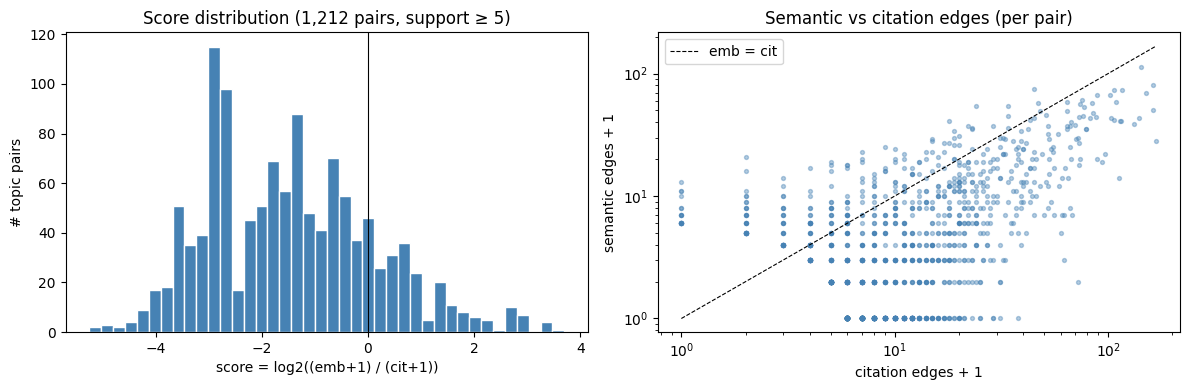

TOP semantic >> citation pairs (candidate missing connections):


,topic_a,words_a,topic_b,words_b,emb_count,cit_count,support,score
0,26,"speech, auditory, auditory feedback, speech motor",78,"aiming, tremor, afferent information, movement",12,0,12,3.700440
1,8,"focus, external, external focus, focus attention",27,"cognitive, exercise, older, physical",10,0,10,3.459432
2,0,"surgical, laparoscopic, skills, surgery",60,"tongue, jaw, oral, masseter",10,0,10,3.459432
3,7,"sequence, sequence learning, implicit, sequences",76,"massed, massed practice, rest, sec",20,1,21,3.392317
4,8,"focus, external, external focus, focus attention",78,"aiming, tremor, afferent information, movement",9,0,9,3.321928
5,20,"conditioning, eyeblink, conditioned, eyeblink conditioning",93,"conditional, associations, arbitrary, monkeys",15,1,16,3.000000
6,42,"mirror, mirror neuron, mirror neurons, action",55,"activity, neuronal, neural, monkeys",7,0,7,3.000000
7,11,"haptic, guidance, haptic guidance, robotic",60,"tongue, jaw, oral, masseter",7,0,7,3.000000
8,58,"bdnf, polymorphism, val66met, genetic",94,"gaba, gaba levels, levels, glx",6,0,6,2.807355
9,54,"adaptation, cerebellar, patients, prism",63,"autism, asd, autistic, autism spectrum",6,0,6,2.807355



TOP citation >> semantic pairs:


,topic_a,words_a,topic_b,words_b,emb_count,cit_count,support,score
0,15,"depression, synaptic, purkinje, longterm depression",39,"pursuit, eye, saccade, spike",0,37,37,-5.247928
1,15,"depression, synaptic, purkinje, longterm depression",31,"vor, gain, vestibular, reflex",1,71,72,-5.169925
2,0,"surgical, laparoscopic, skills, surgery",23,"kr, knowledge results, knowledge, results kr",0,30,30,-4.954196
3,1,"adaptation, visuomotor, visual, errors",75,"abstract available, sep abstract, abstract, available",0,28,28,-4.857981
4,24,"pd, disease, parkinsons, parkinsons disease",42,"mirror, mirror neuron, mirror neurons, action",0,28,28,-4.857981
5,0,"surgical, laparoscopic, skills, surgery",7,"sequence, sequence learning, implicit, sequences",0,24,24,-4.643856
6,14,"pd, disease, patients, parkinsons",45,"connectivity, functional connectivity, restingstate, functional",0,24,24,-4.643856
7,17,"musical, musicians, music, pianists",36,"skill acquisition, job, individual differences, cognitive",0,22,22,-4.523562
8,29,"observational, observational learning, observation, mental",38,"beta, alpha, power, eeg",0,20,20,-4.392317
9,23,"kr, knowledge results, knowledge, results kr",87,"feedback, auditory feedback, auditory, augmented",0,20,20,-4.392317


In [35]:
import matplotlib.pyplot as plt

scored = pair_scores[pair_scores['support'] >= MIN_SUPPORT].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(scored['score'], bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_xlabel('score = log2((emb+1) / (cit+1))')
axes[0].set_ylabel('# topic pairs')
axes[0].set_title(f'Score distribution ({len(scored):,} pairs, support ≥ {MIN_SUPPORT})')

axes[1].scatter(scored['cit_count'] + 1, scored['emb_count'] + 1,
                s=8, alpha=0.4, color='steelblue')
hi = max(scored['emb_count'].max(), scored['cit_count'].max()) + 1
axes[1].plot([1, hi], [1, hi], 'k--', lw=0.8, label='emb = cit')
axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].set_xlabel('citation edges + 1')
axes[1].set_ylabel('semantic edges + 1')
axes[1].set_title('Semantic vs citation edges (per pair)')
axes[1].legend()

plt.tight_layout(); plt.show()


words_by_topic = dict(zip(topic_words['topic_id'], topic_words['words']))

def _label(tid, max_words=4):
    w = words_by_topic.get(tid, '')
    return ', '.join(w.split(' | ')[:max_words]) if w else '(?)'

def _annotate(df_in):
    out = df_in.copy()
    out['words_a'] = out['topic_a'].map(_label)
    out['words_b'] = out['topic_b'].map(_label)
    return out[['topic_a', 'words_a', 'topic_b', 'words_b',
                'emb_count', 'cit_count', 'support', 'score']]

print('TOP semantic >> citation pairs (candidate missing connections):')
display(_annotate(scored.nlargest(10, 'score')).reset_index(drop=True))

print('\nTOP citation >> semantic pairs:')
display(_annotate(scored.nsmallest(10, 'score')).reset_index(drop=True))


## Data quality: placeholder abstracts

Some papers have `[No abstract available]` as their abstract — their SPECTR embeddings are unreliable and they bias the topic / NN analyses (topic 75 is the clearest example). The cell below flags them across the corpus.

In [36]:
PLACEHOLDER_PATTERN = r'no abstract|abstract not available|no abstract available'

docs_lower = df['document'].fillna('').str.lower()
mask_placeholder = docs_lower.str.contains(PLACEHOLDER_PATTERN, regex=True)
df['doc_len'] = df['document'].fillna('').str.len()
mask_short = df['doc_len'] < 200

print(f'Papers in corpus:                       {len(df):,}')
print(f'Papers matching placeholder pattern:    {mask_placeholder.sum():,}  ({100*mask_placeholder.mean():.1f}%)')
print(f'Papers with doc_len < 200 chars:        {mask_short.sum():,}  ({100*mask_short.mean():.1f}%)')
print(f'Either condition:                       {(mask_placeholder | mask_short).sum():,}')

print('\nTopics with the most placeholder papers:')
print(df[mask_placeholder].groupby('topic').size().sort_values(ascending=False).head(8).to_string())

# Sample placeholder papers to inspect manually
subset = df[mask_placeholder]
subset.sample(min(5, len(subset)), random_state=0)[['node_id', 'topic', 'document']]


Papers in corpus:                       14,511
Papers matching placeholder pattern:    175  (1.2%)
Papers with doc_len < 200 chars:        244  (1.7%)
Either condition:                       247

Topics with the most placeholder papers:
topic
-1     82
 75    24
 36     6
 23     5
 74     5
 99     4
 2      4
 16     4


,node_id,topic,document
5519,n8733,75,Learning and stability: a psychophysiological analysis of a case of motor learning with clinical applications [SEP] [No abstract available]
13038,n20595,62,Commentary: Activation of Cortical Somatostatin Interneurons Rescues Synapse Loss and Motor Deficits After Acute MPTP Infusion [SEP] [No abstract available]
6579,n10217,36,A working model of skill acquisition with application to teaching [SEP] [No abstract available]
5565,n8820,75,Motor timing learned without motor training [3] [SEP] [No abstract available]
9317,n14954,-1,The cerebellum gets social [SEP] [No abstract available]
